<a href="https://colab.research.google.com/github/harsh005patel/deep-learning-acad/blob/main/DL_lab_22sep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CFG = dict(
    z_dim=100,
    g_hidden=512,
    d_units=240,
    d_pieces=5,
    batch_size=128,
    epochs=60,
    k=1,
    lr_d=2e-4,
    lr_g=2e-4,
    non_saturating=True,
    real_label=0.9,      # one-sided label smoothing
    seed=0,
)
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

Device: cuda


In [10]:
train_ds = datasets.MNIST("./data", train=True, download=True)
test_ds = datasets.MNIST("./data", train=False, download=True)

X_all = train_ds.data.float().div(255.).view(-1, 784)
X_test = test_ds.data.float().div(255.).view(-1, 784)

X_train, X_val = X_all[:50000], X_all[50000:]
train_loader = DataLoader(TensorDataset(X_train), batch_size=CFG["batch_size"],
                          shuffle=True, drop_last=True)
print(X_train.shape, X_val.shape, X_test.shape)

torch.Size([50000, 784]) torch.Size([10000, 784]) torch.Size([10000, 784])


In [11]:
class Maxout(nn.Module):
    def __init__(self, in_features, out_features, pieces):
        super().__init__()
        self.out_features, self.pieces = out_features, pieces
        self.lin = nn.Linear(in_features, out_features * pieces)

    def forward(self, x):
        h = self.lin(x).view(-1, self.out_features, self.pieces)
        return h.max(dim=2)[0]


class Generator(nn.Module):
    def __init__(self, z_dim, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, 784), nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, units, pieces):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(0.2),
            Maxout(784, units, pieces), nn.Dropout(0.5),
            Maxout(units, units, pieces), nn.Dropout(0.5),
            nn.Linear(units, 1),
        )

    def forward(self, x):
        return self.net(x)


G = Generator(CFG["z_dim"], CFG["g_hidden"]).to(device)
D = Discriminator(CFG["d_units"], CFG["d_pieces"]).to(device)
opt_g = torch.optim.Adam(G.parameters(), lr=CFG["lr_g"], betas=(0.5, 0.999))
opt_d = torch.optim.Adam(D.parameters(), lr=CFG["lr_d"], betas=(0.5, 0.999))
bce = nn.BCEWithLogitsLoss()

def sample_z(n):
    return torch.rand(n, CFG["z_dim"], device=device) * 2 - 1

In [12]:
def show_grid(imgs, nrow=10, title=None, figsize=(8, 8)):
    imgs = imgs.detach().cpu().view(-1, 28, 28).numpy()
    ncol = int(np.ceil(len(imgs) / nrow))
    canvas = np.ones((ncol * 28, nrow * 28))
    for i, im in enumerate(imgs):
        r, c = divmod(i, nrow)
        canvas[r*28:(r+1)*28, c*28:(c+1)*28] = im
    plt.figure(figsize=figsize)
    plt.imshow(canvas, cmap="gray"); plt.axis("off")
    if title: plt.title(title)
    plt.show()

epoch   1 | D loss 0.4591 | G loss 3.3914


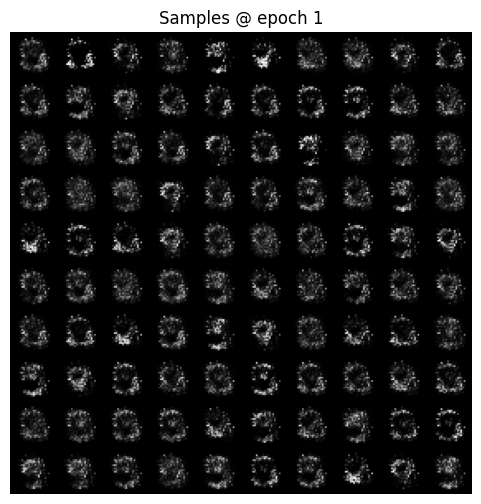

epoch  10 | D loss 0.7775 | G loss 2.5464


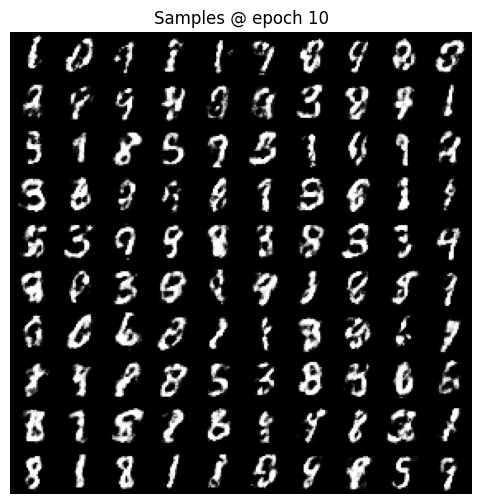

epoch  20 | D loss 0.9481 | G loss 1.8526


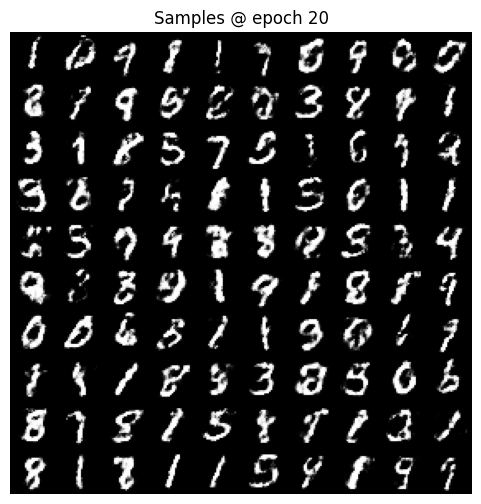

epoch  30 | D loss 1.0202 | G loss 1.5881


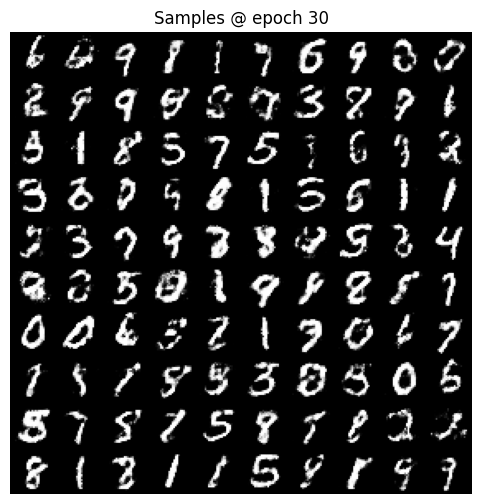

epoch  40 | D loss 1.0683 | G loss 1.4888


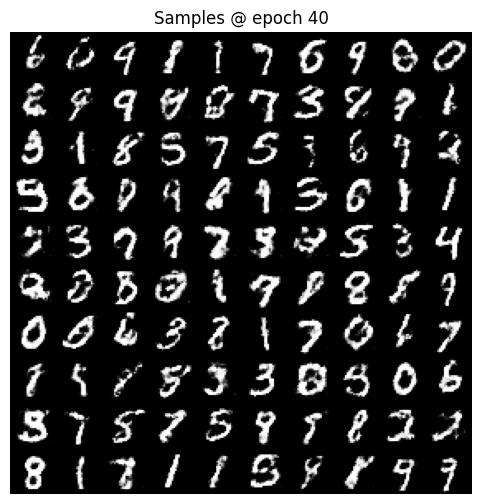

epoch  50 | D loss 1.0852 | G loss 1.4615


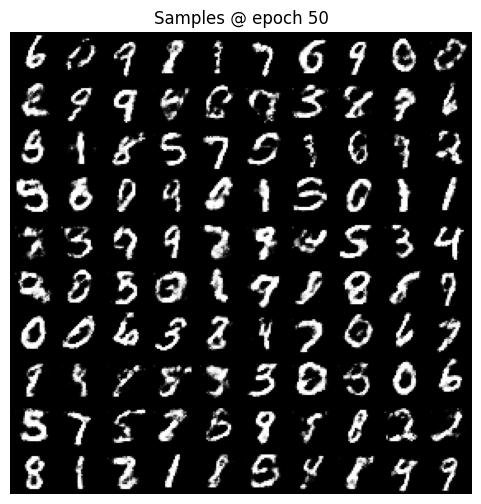

epoch  60 | D loss 1.0778 | G loss 1.4778


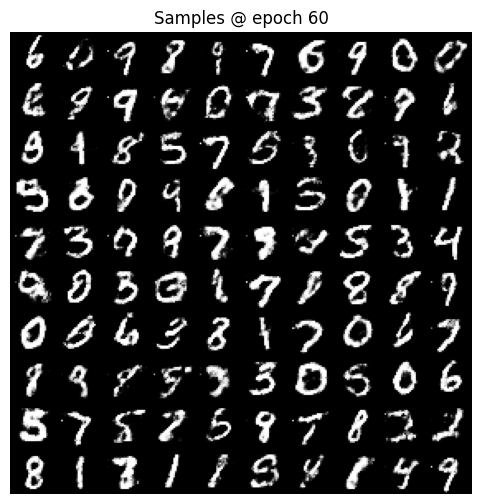

In [16]:
d_hist, g_hist = [], []
fixed_z = sample_z(100)

data_iter = iter(train_loader)
def next_real():
    global data_iter
    try:
        return next(data_iter)[0]
    except StopIteration:
        data_iter = iter(train_loader)
        return next(data_iter)[0]

steps_per_epoch = len(train_loader)
for epoch in range(1, CFG["epochs"] + 1):
    G.train(); D.train()
    d_run, g_run = 0., 0.
    for _ in range(steps_per_epoch):
        # k steps: update D
        for _ in range(CFG["k"]):
            x = next_real().to(device)
            m = x.size(0)
            z = sample_z(m)
            # Removed with torch.no_grad() around G(z)
            with torch.no_grad():
                fake = G(z)
                loss_d = bce(D(x), torch.full((m, 1), CFG["real_label"], device=device)) + \
                   bce(D(fake), torch.zeros(m, 1, device=device))

            fake = G(z)
            loss_d = bce(D(x), torch.full((m, 1), CFG["real_label"], device=device)) + \
               bce(D(fake), torch.zeros(m, 1, device=device))
            opt_d.zero_grad(); loss_d.backward(); opt_d.step()

        # 1 step: update G
        z = sample_z(m)
        logits = D(G(z))
        if CFG["non_saturating"]:
            loss_g = bce(logits, torch.ones(m, 1, device=device))
        else:
            loss_g = -bce(logits, torch.zeros(m, 1, device=device))
        opt_g.zero_grad(); loss_g.backward(); opt_g.step()

        d_run += loss_d.item(); g_run += loss_g.item()

    d_hist.append(d_run / steps_per_epoch); g_hist.append(g_run / steps_per_epoch)
    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | D loss {d_hist[-1]:.4f} | G loss {g_hist[-1]:.4f}")
        G.eval()
        with torch.no_grad():
            show_grid(G(fixed_z), nrow=10, title=f"Samples @ epoch {epoch}", figsize=(6, 6))

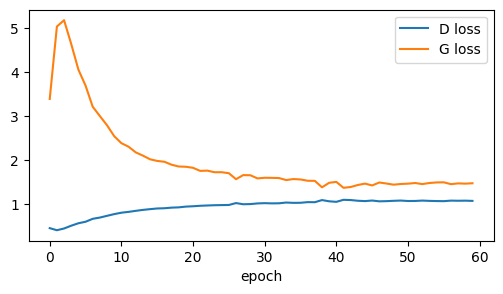

In [17]:
plt.figure(figsize=(6, 3))
plt.plot(d_hist, label="D loss"); plt.plot(g_hist, label="G loss")
plt.xlabel("epoch"); plt.legend(); plt.show()

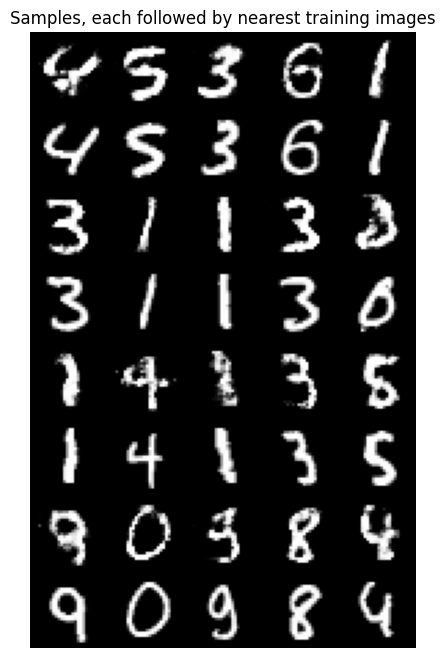

In [18]:
G.eval()
with torch.no_grad():
    s = G(sample_z(20)).cpu()
dists = torch.cdist(s, X_train)
nn_idx = dists.argmin(dim=1)
nearest = X_train[nn_idx]
rows = []
for i in range(0, 20, 5):
    rows.append(torch.cat([s[i:i+5], nearest[i:i+5]], dim=0))
show_grid(torch.cat(rows, 0), nrow=5, title="Samples, each followed by nearest training images", figsize=(5, 8))

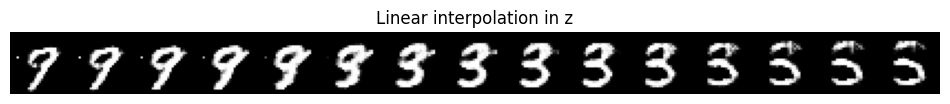

In [20]:
with torch.no_grad():
    z1, z2 = sample_z(1), sample_z(1)
    alphas = torch.linspace(0, 1, 15, device=device).view(-1, 1)
    z_interp = (1 - alphas) * z1 + alphas * z2
    show_grid(G(z_interp), nrow=15, title="Linear interpolation in z", figsize=(12, 2))

In [21]:
@torch.no_grad()
def parzen_ll(samples, data, sigma, batch=500):
    n, d = samples.shape
    const = -np.log(n) - 0.5 * d * np.log(2 * np.pi * sigma**2)
    total = []
    for i in range(0, len(data), batch):
        xb = data[i:i+batch]
        d2 = torch.cdist(xb, samples) ** 2
        lse = torch.logsumexp(-d2 / (2 * sigma**2), dim=1)
        total.append(lse + const)
    return torch.cat(total).mean().item(), torch.cat(total)

@torch.no_grad()
def generate(n, chunk=5000):
    out = []
    for i in range(0, n, chunk):
        out.append(G(sample_z(min(chunk, n - i))))
    return torch.cat(out)

G.eval()
gen_samples = generate(10000)
Xv, Xt = X_val.to(device), X_test.to(device)

# pick sigma on the validation set
sigmas = np.logspace(-1.5, 0, 15)
val_scores = [parzen_ll(gen_samples, Xv[:2000], s)[0] for s in sigmas]
best_sigma = sigmas[int(np.argmax(val_scores))]
print("best sigma:", best_sigma)

mean_ll, per_example = parzen_ll(gen_samples, Xt, best_sigma)
se = (per_example.std() / np.sqrt(len(per_example))).item()
print(f"Parzen log-likelihood on MNIST test: {mean_ll:.1f} +/- {se:.1f}")

best sigma: 0.1778279410038923
Parzen log-likelihood on MNIST test: 149.4 +/- 2.2


In [22]:
torch.save(G.state_dict(), "generator_mnist.pt")